<a href="https://colab.research.google.com/github/Trivikram918/Case-studies-in-Data-Science/blob/main/Case%20study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
Stroke dataset shape: (5110, 12)
      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4       1

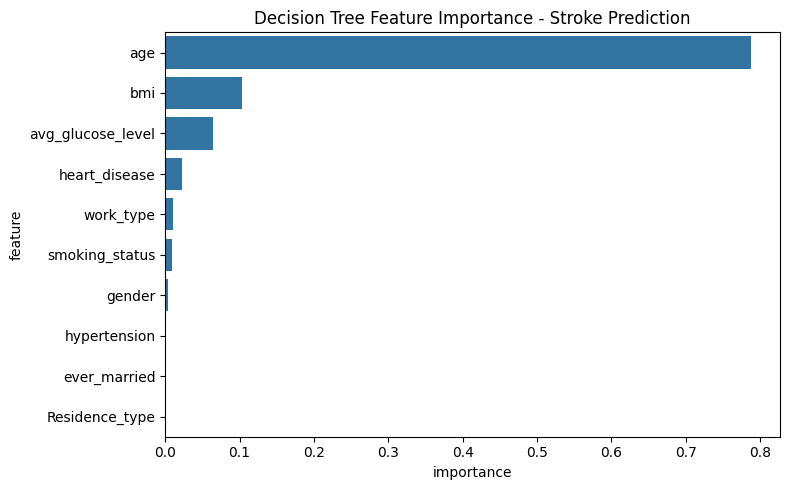

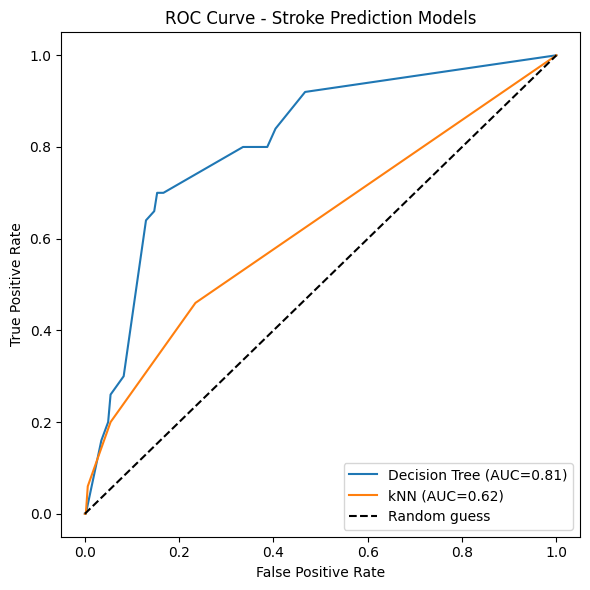

Fraud dataset shape: (10000, 20)
  Provider_ID  Claim_ID  Patient_Age Patient_Gender Diagnosis_Code  \
0       P0052  C0000000           37           Male         I25.10   
1       P0121  C0000001           21         Female          E11.9   
2       P0140  C0000002           78         Female          J06.9   
3       P0202  C0000003           65           Male            I10   
4       P0135  C0000004           36           Male          M54.5   

   Procedure_Code  Claim_Amount  Approved_Amount Insurance_Type  \
0           36415        443.51           393.16       Medicaid   
1           99213        467.50           461.33       Self-Pay   
2           93000        591.69           530.06       Medicaid   
3           93000        235.15           189.11        Private   
4           85025        487.96           369.91        Private   

  Claim_Submission_Date  Days_Between_Service_and_Claim  \
0            2024-09-01                              13   
1            2022-09-05  

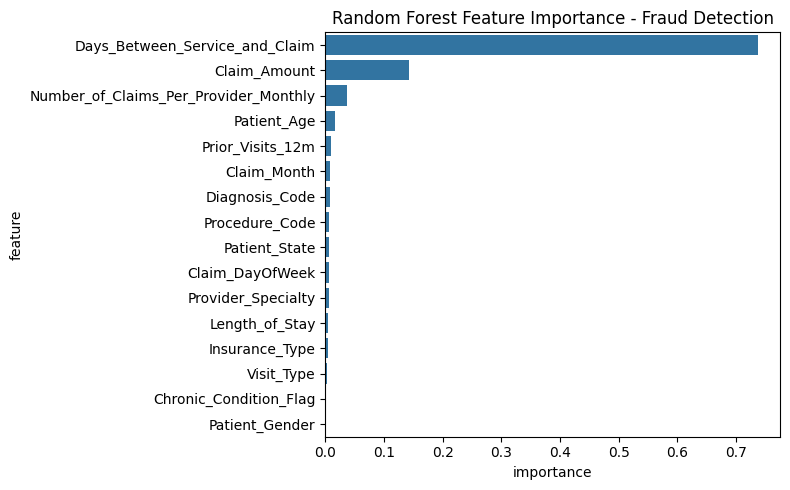

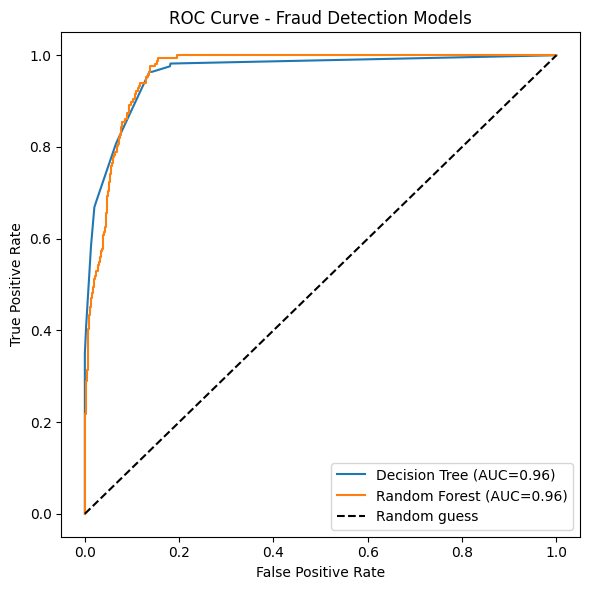


=== COMBINED RESULTS ACROSS BOTH DATASETS ===
                    model  accuracy  precision    recall        f1   roc_auc
0  Stroke - Decision Tree  0.826810   0.177665  0.700000  0.283401  0.810226
1            Stroke - kNN  0.949119   0.000000  0.000000  0.000000  0.624588
2   Fraud - Decision Tree  0.866500   0.380048  0.963855  0.545145  0.961581
3   Fraud - Random Forest  0.877000   0.398477  0.945783  0.560714  0.963159


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
# =====================================================================
# Part 1.3 - Data Analysis (Combined Notebook)
# Dataset 1: Stroke Prediction  -> Decision Tree + kNN
# Dataset 2: Healthcare Fraud Detection -> Decision Tree + Random Forest
# =====================================================================

# ---------------------------------------------------------------
# CELL 1: Mount Google Drive
# ---------------------------------------------------------------
from google.colab import drive
drive.mount('/content/drive')

# ---------------------------------------------------------------
# CELL 2: Imports
# ---------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)
from sklearn.impute import SimpleImputer

RANDOM_STATE = 42

def evaluate(name, y_true, y_pred, y_proba):
    print(f"\n--- {name} ---")
    print("Accuracy: ", round(accuracy_score(y_true, y_pred), 3))
    print("Precision:", round(precision_score(y_true, y_pred, zero_division=0), 3))
    print("Recall:   ", round(recall_score(y_true, y_pred, zero_division=0), 3))
    print("F1-score: ", round(f1_score(y_true, y_pred, zero_division=0), 3))
    print("ROC-AUC:  ", round(roc_auc_score(y_true, y_proba), 3))
    print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
    }

# =====================================================================
# CELL 3: DATASET 1 - STROKE PREDICTION
# =====================================================================

stroke_path = "/content/drive/MyDrive/healthcare-dataset-stroke-data.csv"

stroke_df = pd.read_csv(stroke_path)
print("Stroke dataset shape:", stroke_df.shape)
print(stroke_df.head())
print(stroke_df.isnull().sum())

# --- Clean & preprocess ---
stroke_df = stroke_df.drop(columns=["id"])
imputer = SimpleImputer(strategy="median")
stroke_df["bmi"] = imputer.fit_transform(stroke_df[["bmi"]])

cat_cols = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]
for col in cat_cols:
    le = LabelEncoder()
    stroke_df[col] = le.fit_transform(stroke_df[col])

# --- Train/test split ---
X = stroke_df.drop(columns=["stroke"])
y = stroke_df["stroke"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Model 1: Decision Tree ---
dt_model = DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=RANDOM_STATE)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_proba = dt_model.predict_proba(X_test)[:, 1]

# --- Model 2: kNN ---
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train_scaled, y_train)
knn_pred = knn_model.predict(X_test_scaled)
knn_proba = knn_model.predict_proba(X_test_scaled)[:, 1]

# --- Evaluate ---
stroke_dt_results = evaluate("Stroke - Decision Tree", y_test, dt_pred, dt_proba)
stroke_knn_results = evaluate("Stroke - kNN", y_test, knn_pred, knn_proba)

stroke_results_df = pd.DataFrame([stroke_dt_results, stroke_knn_results])
print("\nStroke summary table:\n", stroke_results_df)

# --- Feature importance ---
importance_df = pd.DataFrame({
    "feature": X.columns, "importance": dt_model.feature_importances_
}).sort_values("importance", ascending=False)
print("\nStroke feature importances:\n", importance_df)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x="importance", y="feature")
plt.title("Decision Tree Feature Importance - Stroke Prediction")
plt.tight_layout()
plt.savefig("stroke_feature_importance.png", dpi=150)
plt.show()

# --- ROC curve ---
plt.figure(figsize=(6, 6))
for name, proba in [("Decision Tree", dt_proba), ("kNN", knn_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.2f})")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Stroke Prediction Models"); plt.legend()
plt.tight_layout()
plt.savefig("stroke_roc_curve.png", dpi=150)
plt.show()

# =====================================================================
# CELL 4: DATASET 2 - HEALTHCARE FRAUD DETECTION
# =====================================================================

fraud_path = "/content/drive/MyDrive/healthcare_fraud_detection.csv"

fraud_df = pd.read_csv(fraud_path)
print("Fraud dataset shape:", fraud_df.shape)
print(fraud_df.head())
print(fraud_df.isnull().sum())

# ---------------------------------------------------------------
# DATA LEAKAGE CHECK - do this BEFORE encoding/training
# Claim_Status (Approved/Pending/Rejected) is very likely assigned
# AFTER a claim has already been reviewed for fraud - a claim is
# typically marked "Rejected" partly BECAUSE it was flagged as
# fraudulent. Including it would let the model see the answer
# rather than genuinely learn fraud patterns from the source
# claim/provider data. We inspect it, then drop it.
# ---------------------------------------------------------------
print("\nClaim_Status vs Is_Fraud crosstab (evidence for leakage decision):")
print(pd.crosstab(fraud_df["Claim_Status"], fraud_df["Is_Fraud"]))

fraud_df = fraud_df.drop(columns=["Claim_Status"])

# --- Diagnostic: check Approved_Amount / Amount_Gap for leakage ---
_check = fraud_df.copy()
_check["Amount_Gap_check"] = _check["Claim_Amount"] - _check["Approved_Amount"]
_check["Amount_Gap_Ratio_check"] = _check["Amount_Gap_check"] / _check["Claim_Amount"]
print("\nAmount_Gap_Ratio by fraud status (evidence for leakage decision):")
print(_check.groupby("Is_Fraud")[["Amount_Gap_check", "Amount_Gap_Ratio_check"]].describe())
del _check

# ---------------------------------------------------------------
# DATA LEAKAGE CHECK #2 - Approved_Amount
# The diagnostic crosstab/groupby showed fraud=1 claims have a
# dramatically different Amount_Gap_Ratio (mean 0.45, range 0.20-0.70)
# than fraud=0 claims (mean 0.12, range 0.00-0.25), with almost no
# overlap. This happens because Approved_Amount is set by the insurer
# AFTER a claim is reviewed - it reflects the fraud decision rather
# than predicting it. Approved_Amount and anything derived from it
# must be dropped, as they leak the outcome.
# ---------------------------------------------------------------
fraud_df = fraud_df.drop(columns=["Approved_Amount"])

# --- Clean & preprocess ---
fraud_df = fraud_df.drop(columns=["Provider_ID", "Claim_ID"])

fraud_df["Claim_Submission_Date"] = pd.to_datetime(fraud_df["Claim_Submission_Date"])
fraud_df["Claim_Month"] = fraud_df["Claim_Submission_Date"].dt.month
fraud_df["Claim_DayOfWeek"] = fraud_df["Claim_Submission_Date"].dt.dayofweek
fraud_df = fraud_df.drop(columns=["Claim_Submission_Date"])

# Automatically detect and encode ALL remaining text/categorical columns
cat_cols = fraud_df.select_dtypes(include=['object']).columns.tolist()
print("Encoding these categorical columns:", cat_cols)

for col in cat_cols:
    le = LabelEncoder()
    fraud_df[col] = le.fit_transform(fraud_df[col].astype(str))

# --- Train/test split ---
X2 = fraud_df.drop(columns=["Is_Fraud"])
y2 = fraud_df["Is_Fraud"]
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=RANDOM_STATE, stratify=y2
)

# --- Model 1: Decision Tree ---
dt2_model = DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=RANDOM_STATE)
dt2_model.fit(X2_train, y2_train)
dt2_pred = dt2_model.predict(X2_test)
dt2_proba = dt2_model.predict_proba(X2_test)[:, 1]

# --- Model 2: Random Forest ---
rf_model = RandomForestClassifier(n_estimators=200, max_depth=8, class_weight="balanced", random_state=RANDOM_STATE)
rf_model.fit(X2_train, y2_train)
rf_pred = rf_model.predict(X2_test)
rf_proba = rf_model.predict_proba(X2_test)[:, 1]

# --- Evaluate ---
fraud_dt_results = evaluate("Fraud - Decision Tree", y2_test, dt2_pred, dt2_proba)
fraud_rf_results = evaluate("Fraud - Random Forest", y2_test, rf_pred, rf_proba)

fraud_results_df = pd.DataFrame([fraud_dt_results, fraud_rf_results])
print("\nFraud summary table:\n", fraud_results_df)

# --- Feature importance ---
importance_df2 = pd.DataFrame({
    "feature": X2.columns, "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)
print("\nFraud feature importances:\n", importance_df2)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df2, x="importance", y="feature")
plt.title("Random Forest Feature Importance - Fraud Detection")
plt.tight_layout()
plt.savefig("fraud_feature_importance.png", dpi=150)
plt.show()

# --- ROC curve ---
plt.figure(figsize=(6, 6))
for name, proba in [("Decision Tree", dt2_proba), ("Random Forest", rf_proba)]:
    fpr, tpr, _ = roc_curve(y2_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y2_test, proba):.2f})")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Fraud Detection Models"); plt.legend()
plt.tight_layout()
plt.savefig("fraud_roc_curve.png", dpi=150)
plt.show()

# =====================================================================
# CELL 5: Combined summary (both datasets side by side)
# =====================================================================
all_results = pd.concat([stroke_results_df, fraud_results_df], ignore_index=True)
print("\n=== COMBINED RESULTS ACROSS BOTH DATASETS ===")
print(all_results)
all_results.to_csv("combined_results_summary.csv", index=False)

# --- Download everything at the end ---
from google.colab import files
for f in ["stroke_feature_importance.png", "stroke_roc_curve.png",
          "fraud_feature_importance.png", "fraud_roc_curve.png",
          "combined_results_summary.csv"]:
    files.download(f)